In [4]:
# Cell 1: IMPORTS - RUN THIS FIRST!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ All packages imported successfully!")

✅ All packages imported successfully!


In [8]:
# Cell 2: LOAD YOUR CSV DATA - CORRECTED PATH
try:
    # Go up one level to find the Data folder
    df = pd.read_csv('../Data/raw_analyst_ratings.csv')

    print(f"✅ CSV data loaded successfully! Shape: {df.shape}")
    print("\n📊 Columns:", df.columns.tolist())
    print("\n📝 Data types:")
    print(df.dtypes)
    print("\n👀 First 5 rows:")
    display(df.head())

except FileNotFoundError:
    print("❌ File not found with corrected path!")

    # Debug the actual location
    import os
    print(f"\n🔍 DEBUGGING PATHS:")
    print(f"Current directory: {os.getcwd()}")

    # Check parent directory
    parent_dir = os.path.dirname(os.getcwd())
    print(f"Parent directory: {parent_dir}")

    if os.path.exists(parent_dir):
        print("Files in parent directory:")
        for file in os.listdir(parent_dir):
            print(f"  - {file}")

        # Check if Data folder exists in parent
        data_path = os.path.join(parent_dir, 'Data')
        if os.path.exists(data_path):
            print(f"Files in {data_path}:")
            for file in os.listdir(data_path):
                print(f"  - {file}")

except Exception as e:
    print(f"❌ Error loading CSV file: {e}")

✅ CSV data loaded successfully! Shape: (1407328, 6)

📊 Columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']

📝 Data types:
Unnamed: 0     int64
headline      object
url           object
publisher     object
date          object
stock         object
dtype: object

👀 First 5 rows:


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [9]:
# Cell 4: COMPREHENSIVE DATA EXPLORATION
print("="*60)
print("📈 COMPREHENSIVE EXPLORATORY DATA ANALYSIS")
print("="*60)

# 1. Basic Information
print("\n1. 📋 BASIC DATASET INFO")
print(f"   • Rows: {df.shape[0]:,}")
print(f"   • Columns: {df.shape[1]}")
print(f"   • Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 2. Missing Values Analysis
print("\n2. 🗑️ MISSING VALUES ANALYSIS")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing %': missing_percent
}).sort_values('Missing Count', ascending=False)

display(missing_df[missing_df['Missing Count'] > 0])

# 3. Check for duplicates
print("\n3. 🔍 DUPLICATE ANALYSIS")
print(f"   • Total duplicate rows: {df.duplicated().sum()}")
print(f"   • Duplicate headlines: {df['headline'].duplicated().sum()}")

📈 COMPREHENSIVE EXPLORATORY DATA ANALYSIS

1. 📋 BASIC DATASET INFO
   • Rows: 1,407,328
   • Columns: 6
   • Memory usage: 634.55 MB

2. 🗑️ MISSING VALUES ANALYSIS


,Missing Count,Missing %



3. 🔍 DUPLICATE ANALYSIS
   • Total duplicate rows: 0
   • Duplicate headlines: 561558



4. 📅 TEMPORAL ANALYSIS
Sample dates before conversion:
['2020-06-05 10:30:54-04:00', '2020-06-03 10:45:20-04:00', '2020-05-26 04:30:07-04:00']
❌ Error in date conversion: time data "2020-05-22 00:00:00" doesn't match format "%Y-%m-%d %H:%M:%S%z", at position 10. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.
Trying alternative date parsing...
✅ Date conversion successful with alternative method!
   • Date range: 2009-02-14 to 2020-06-11
   • Average articles per day: 355.8
   • Maximum articles in one day: 2739


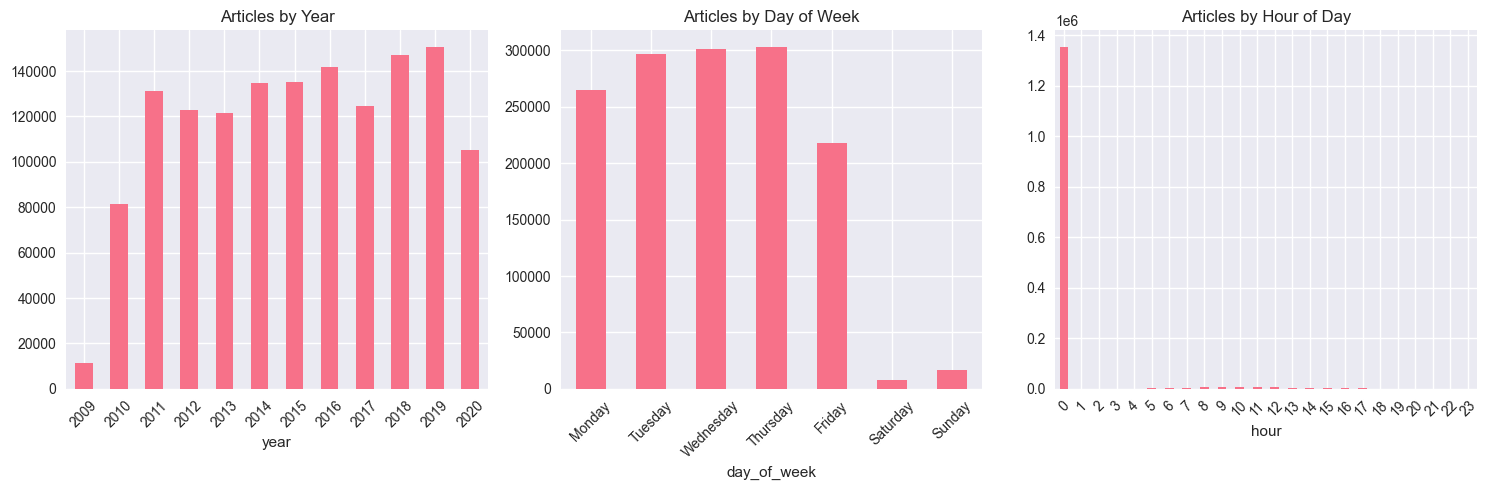


📊 Temporal Patterns:
   • Busiest day: Thursday
   • Busiest hour: 0:00
   • Most active year: 2019


In [11]:
# Cell 5: TEMPORAL ANALYSIS - CORRECTED
print("\n4. 📅 TEMPORAL ANALYSIS")

# Convert date to datetime - handle the timezone format
try:
    # First, let's see what the date format looks like
    print("Sample dates before conversion:")
    print(df['date'].head(3).tolist())

    # Convert date - handle the UTC-4 timezone format
    df['date'] = pd.to_datetime(df['date'], utc=True)
    df['date_only'] = df['date'].dt.date
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day_of_week'] = df['date'].dt.day_name()
    df['hour'] = df['date'].dt.hour

    print(f"✅ Date conversion successful!")
    print(f"   • Date range: {df['date_only'].min()} to {df['date_only'].max()}")
    print(f"   • Total days covered: {(df['date_only'].max() - df['date_only'].min()).days} days")

except Exception as e:
    print(f"❌ Error in date conversion: {e}")
    print("Trying alternative date parsing...")

    # Alternative approach: remove timezone info first
    df['date_clean'] = df['date'].str.split('-04:00').str[0]
    df['date'] = pd.to_datetime(df['date_clean'])
    df['date_only'] = df['date'].dt.date
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day_of_week'] = df['date'].dt.day_name()
    df['hour'] = df['date'].dt.hour

    print(f"✅ Date conversion successful with alternative method!")
    print(f"   • Date range: {df['date_only'].min()} to {df['date_only'].max()}")

# Articles over time
daily_counts = df.groupby('date_only').size()
print(f"   • Average articles per day: {daily_counts.mean():.1f}")
print(f"   • Maximum articles in one day: {daily_counts.max()}")

# Plot publication frequency
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
df['year'].value_counts().sort_index().plot(kind='bar')
plt.title('Articles by Year')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
df['day_of_week'].value_counts().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']).plot(kind='bar')
plt.title('Articles by Day of Week')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
df['hour'].value_counts().sort_index().plot(kind='bar')
plt.title('Articles by Hour of Day')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Show temporal patterns
print(f"\n📊 Temporal Patterns:")
print(f"   • Busiest day: {df['day_of_week'].value_counts().index[0]}")
print(f"   • Busiest hour: {df['hour'].value_counts().index[0]}:00")
print(f"   • Most active year: {df['year'].value_counts().index[0]}")


5. 🏢 PUBLISHER ANALYSIS
   • Total unique publishers: 1034
   • Top 10 publishers:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

6. 📊 STOCK ANALYSIS
   • Total unique stocks: 6204
   • Top 15 most mentioned stocks:
stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
QQQ     3106
NFLX    3028
M       3025
EBAY    3018
GILD    2968
VZ      2966
QCOM    2941
JNJ     2928
DAL     2926
BABA    2858
KO      2797
Name: count, dtype: int64


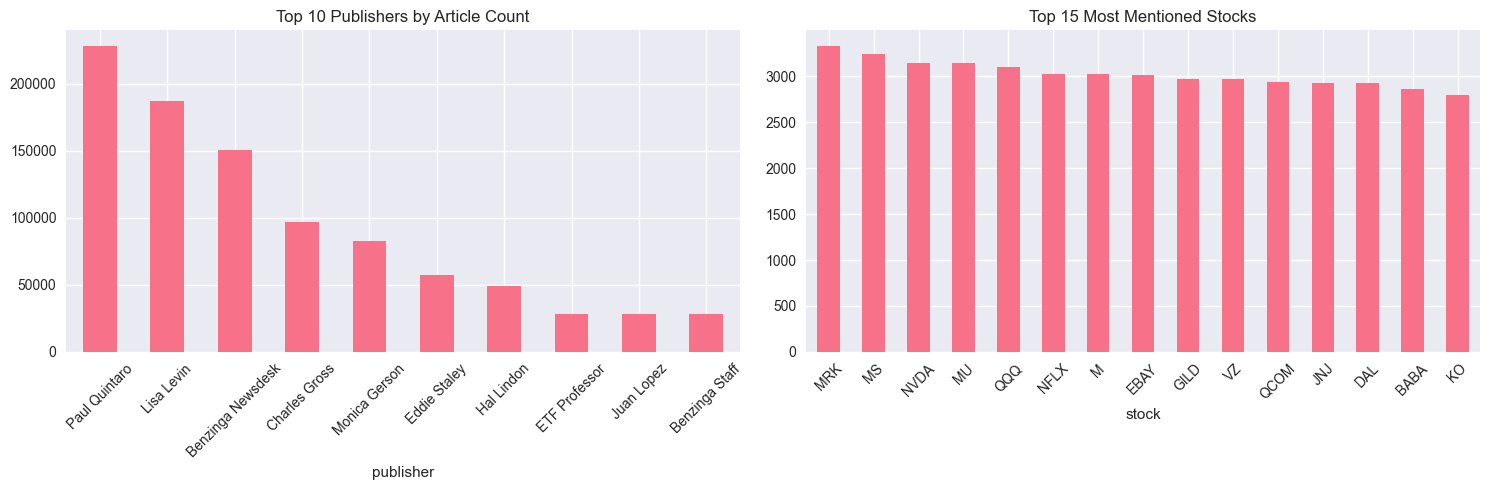

In [12]:
# Cell 6: PUBLISHER AND STOCK ANALYSIS
print("\n5. 🏢 PUBLISHER ANALYSIS")
publisher_stats = df['publisher'].value_counts()
print(f"   • Total unique publishers: {len(publisher_stats)}")
print(f"   • Top 10 publishers:")
print(publisher_stats.head(10))

print("\n6. 📊 STOCK ANALYSIS")
stock_stats = df['stock'].value_counts()
print(f"   • Total unique stocks: {len(stock_stats)}")
print(f"   • Top 15 most mentioned stocks:")
print(stock_stats.head(15))

# Plot top publishers and stocks
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
publisher_stats.head(10).plot(kind='bar')
plt.title('Top 10 Publishers by Article Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
stock_stats.head(15).plot(kind='bar')
plt.title('Top 15 Most Mentioned Stocks')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


7. 📰 HEADLINE TEXT ANALYSIS
   • Average headline length: 73.1 characters
   • Average word count: 11.4 words
   • Longest headline: 512 characters
   • Shortest headline: 3 characters


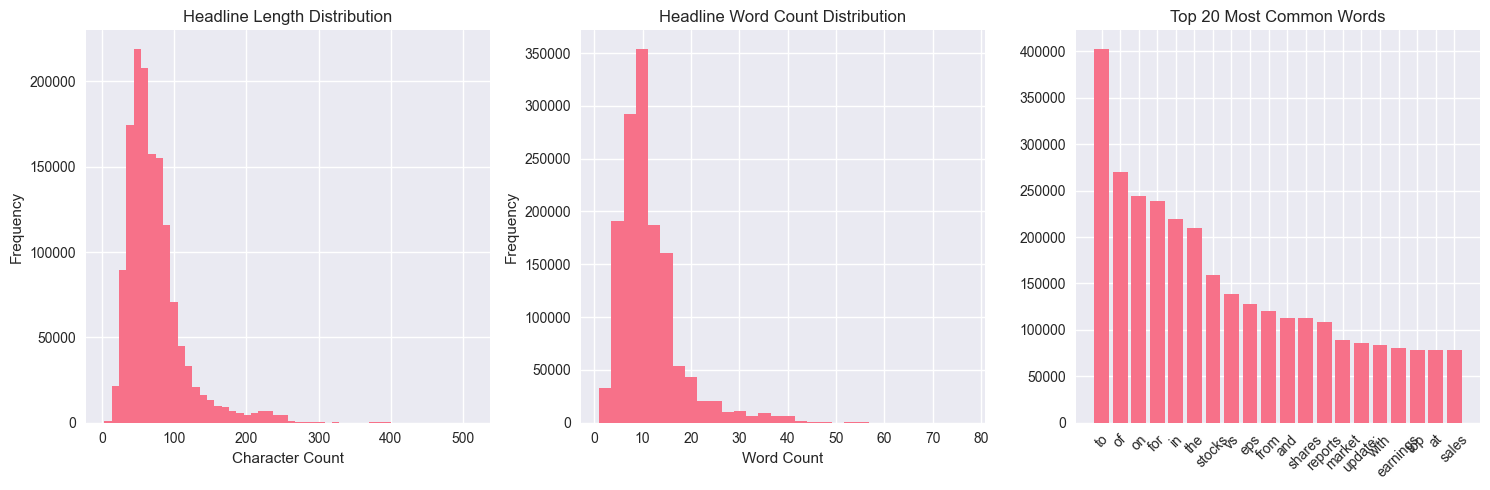


8. 👀 SAMPLE HEADLINES BY CATEGORY
   Short headlines (<30 chars):
     1. 71 Biggest Movers From Friday
     2. All Mixed Up
     3. Agilent Raises FY Outlook

   Long headlines (>100 chars):
     1. Agilent Technologies shares are trading higher after the company reported better-than-expected Q2 EPS and sales results.
     2. Agilent Technologies shares are trading higher after the company reported better-than-expected Q2 EPS and sales results.
     3. Shares of several healthcare companies are trading higher amid positive investor sentiment as some US states begin to reopen their economies and as oil prices gain for the session.


In [14]:
# Cell 7: TEXT ANALYSIS - HEADLINE EXPLORATION
print("\n7. 📰 HEADLINE TEXT ANALYSIS")

# Calculate headline statistics
df['headline_length'] = df['headline'].str.len()
df['headline_word_count'] = df['headline'].str.split().str.len()

print(f"   • Average headline length: {df['headline_length'].mean():.1f} characters")
print(f"   • Average word count: {df['headline_word_count'].mean():.1f} words")
print(f"   • Longest headline: {df['headline_length'].max()} characters")
print(f"   • Shortest headline: {df['headline_length'].min()} characters")

# Plot headline statistics
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
df['headline_length'].hist(bins=50)
plt.title('Headline Length Distribution')
plt.xlabel('Character Count')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
df['headline_word_count'].hist(bins=30)
plt.title('Headline Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
# Most common words in headlines
from collections import Counter
all_words = ' '.join(df['headline'].str.lower()).split()
common_words = Counter(all_words).most_common(20)
words, counts = zip(*common_words)
plt.bar(range(len(words)), counts)
plt.title('Top 20 Most Common Words')
plt.xticks(range(len(words)), words, rotation=45)

plt.tight_layout()
plt.show()

# Show sample headlines
print("\n8. 👀 SAMPLE HEADLINES BY CATEGORY")
print("   Short headlines (<30 chars):")
short_headlines = df[df['headline_length'] < 30]['headline'].head(3).tolist()
for i, hl in enumerate(short_headlines, 1):
    print(f"     {i}. {hl}")

print("\n   Long headlines (>100 chars):")
long_headlines = df[df['headline_length'] > 100]['headline'].head(3).tolist()
for i, hl in enumerate(long_headlines, 1):
    print(f"     {i}. {hl}")


9. 💰 FINANCIAL TERM FREQUENCY ANALYSIS
   • Earnings: 141815 mentions
   • Price Target: 188115 mentions
   • Upgrade Downgrade: 219152 mentions
   • Buy Sell: 182349 mentions
   • High Low: 295842 mentions
   • Analyst: 134252 mentions


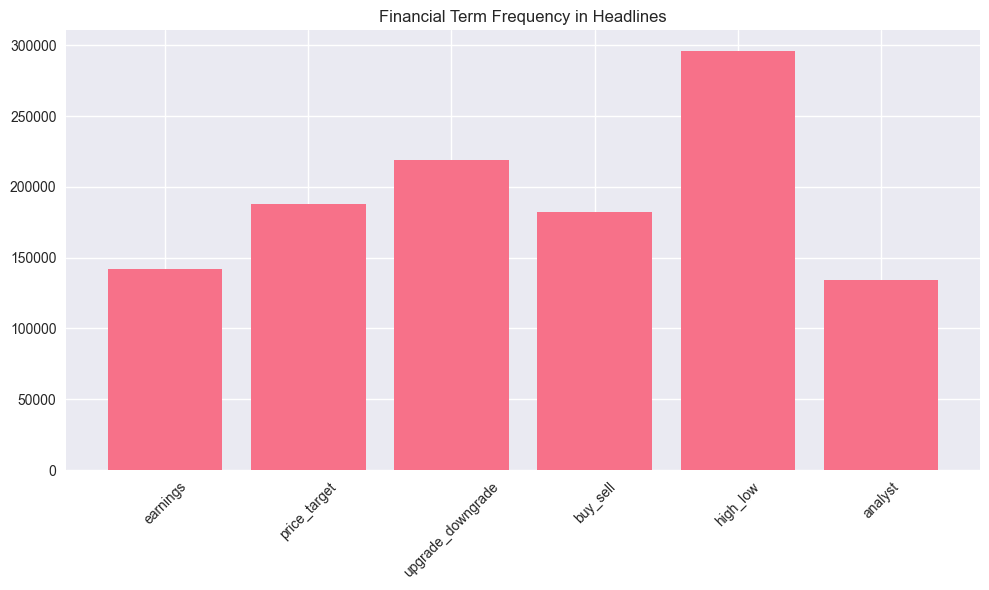

In [15]:
# Cell 8: FINANCIAL TERM ANALYSIS
print("\n9. 💰 FINANCIAL TERM FREQUENCY ANALYSIS")

# Common financial terms to track
financial_terms = {
    'earnings': ['earnings', 'profit', 'revenue', 'income'],
    'price_target': ['price target', 'target price', 'pt'],
    'upgrade_downgrade': ['upgrade', 'downgrade', 'maintains', 'initiate'],
    'buy_sell': ['buy', 'sell', 'hold', 'outperform', 'underperform'],
    'high_low': ['high', 'low', '52-week', 'record'],
    'analyst': ['analyst', 'maintains', 'rating', 'coverage']
}

term_counts = {}
for category, terms in financial_terms.items():
    count = 0
    for term in terms:
        count += df['headline'].str.lower().str.contains(term, na=False).sum()
    term_counts[category] = count
    print(f"   • {category.replace('_', ' ').title()}: {count} mentions")

# Plot financial term frequency
plt.figure(figsize=(10, 6))
plt.bar(term_counts.keys(), term_counts.values())
plt.title('Financial Term Frequency in Headlines')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# Cell 9: SUMMARY STATISTICS
print("="*60)
print("📊 EDA SUMMARY")
print("="*60)

summary_stats = {
    "Total Articles": f"{len(df):,}",
    "Date Range": f"{df['date_only'].min()} to {df['date_only'].max()}",
    "Time Span": f"{(df['date_only'].max() - df['date_only'].min()).days} days",
    "Unique Stocks": df['stock'].nunique(),
    "Unique Publishers": df['publisher'].nunique(),
    "Most Active Publisher": f"{df['publisher'].value_counts().index[0]} ({df['publisher'].value_counts().iloc[0]:,} articles)",
    "Most Mentioned Stock": f"{df['stock'].value_counts().index[0]} ({df['stock'].value_counts().iloc[0]:,} mentions)",
    "Average Articles per Day": f"{daily_counts.mean():.1f}",
    "Average Headline Length": f"{df['headline_length'].mean():.1f} characters",
    "Average Word Count": f"{df['headline_word_count'].mean():.1f} words",
    "Busiest Day": f"{df['day_of_week'].value_counts().index[0]}",
    "Busiest Hour": f"{df['hour'].value_counts().index[0]}:00"
}

for key, value in summary_stats.items():
    print(f"• {key}: {value}")

print("\n✅ EDA COMPLETED! Ready for Task 2: Technical Analysis")

📊 EDA SUMMARY
• Total Articles: 1,407,328
• Date Range: 2009-02-14 to 2020-06-11
• Time Span: 4135 days
• Unique Stocks: 6204
• Unique Publishers: 1034
• Most Active Publisher: Paul Quintaro (228,373 articles)
• Most Mentioned Stock: MRK (3,333 mentions)
• Average Articles per Day: 355.8
• Average Headline Length: 73.1 characters
• Average Word Count: 11.4 words
• Busiest Day: Thursday
• Busiest Hour: 0:00

✅ EDA COMPLETED! Ready for Task 2: Technical Analysis


In [17]:
# Cell 10: SAVE CLEANED DATA FOR NEXT TASKS
# Save a cleaned version for future tasks
df.to_csv('../Data/cleaned_financial_news.csv', index=False)
print("💾 Cleaned data saved to: ../Data/cleaned_financial_news.csv")

# Make your first commit for Task 1

💾 Cleaned data saved to: ../Data/cleaned_financial_news.csv

🎯 NEXT STEPS:
1. Commit your work: git add . && git commit -m 'feat: complete EDA for financial news data'
2. Push to GitHub: git push origin task-1
3. Start Task 2: Technical Analysis with PyNance and TA-Lib
